In [1]:
import json
import os
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image

# ==========================================
# 1. PATHS & DATASET CLASS
# ==========================================
BASE_KAGGLE_DIR = "/kaggle/input/datasets/hrushi1998/vr-mini-proj-dataset/Trimmed_Dataset" 
TRAIN_DIR = f"{BASE_KAGGLE_DIR}/trimmed_train_data"
VAL_DIR = f"{BASE_KAGGLE_DIR}/trimmed_val_data"
TRAIN_JSON_PATH = f"{TRAIN_DIR}/processed_train_data.json"
VAL_JSON_PATH = f"{VAL_DIR}/processed_val_data.json"

class KaggleClothingDataset(Dataset):
    def __init__(self, json_file, img_dir, transform=None):
        with open(json_file, 'r') as f:
            full_data = json.load(f)
            
        self.data = full_data["data"]
        self.top_5_categories = full_data.get("top_5_categories", [1, 8, 7, 2, 9])
        self.transform = transform
        self.img_dir = img_dir
        self.label_map = {cat_id: idx for idx, cat_id in enumerate(self.top_5_categories)}

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        full_image_path = os.path.join(self.img_dir, item["image_path"])
        
        try:
            image = Image.open(full_image_path).convert('RGB')
        except Exception:
            return torch.zeros((3, 224, 224)), torch.zeros(5)

        if self.transform:
            image = self.transform(image)

        target = torch.zeros(5, dtype=torch.float32)
        for cat_id in item["classification_labels"]:
            if cat_id in self.label_map:
                target[self.label_map[cat_id]] = 1.0

        return image, target

# ==========================================
# 2. TRANSFORMS & SPLITTING
# ==========================================
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop((224, 224)), 
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Loading datasets into memory...")
train_dataset = KaggleClothingDataset(TRAIN_JSON_PATH, TRAIN_DIR, transform=train_transforms)
full_val_dataset = KaggleClothingDataset(VAL_JSON_PATH, VAL_DIR, transform=eval_transforms)

val_size = len(full_val_dataset) // 2
test_size = len(full_val_dataset) - val_size

val_dataset, test_dataset = random_split(
    full_val_dataset, 
    [val_size, test_size], 
    generator=torch.Generator().manual_seed(42) 
)

BATCH_SIZE = 128  
NUM_WORKERS = 4  

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"✅ Dataset Splitting Complete! Batches of {BATCH_SIZE} ready.")

Loading datasets into memory...
✅ Dataset Splitting Complete! Batches of 128 ready.


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision.models import EfficientNet_B0_Weights
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ==========================================
# 1. BUILD EFFICIENTNET-B0 & DISTRIBUTE
# ==========================================
print("Loading Pre-trained EfficientNet-B0...")
weights = EfficientNet_B0_Weights.DEFAULT
model_effnet = models.efficientnet_b0(weights=weights)

# Freeze the backbone 
for param in model_effnet.parameters():
    param.requires_grad = False

# Replace final classification head for our 5 classes
num_classes = 5 
in_features = model_effnet.classifier[1].in_features
model_effnet.classifier[1] = nn.Linear(in_features, num_classes)

#THE DUAL-GPU MAGIC LINE
if torch.cuda.device_count() > 1:
    print(f"Splitting work across {torch.cuda.device_count()} GPUs!")
    model_effnet = nn.DataParallel(model_effnet)

model_effnet = model_effnet.to(device)

# ==========================================
# 2. LOSS, OPTIMIZER & METRICS
# ==========================================
criterion = nn.BCEWithLogitsLoss()

# If wrapped in DataParallel, we must access the module to get the specific classifier parameters
trainable_params = model_effnet.module.classifier.parameters() if isinstance(model_effnet, nn.DataParallel) else model_effnet.classifier.parameters()
optimizer = optim.Adam(trainable_params, lr=0.001)

# ==========================================
# 3. HIGH-SPEED TRAINING LOOP
# ==========================================
num_epochs = 20
best_val_loss = float('inf') 

print("\n🚀 Starting EfficientNet-B0 Training...")

for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    model_effnet.train()
    running_loss = 0.0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model_effnet(inputs)
        
        loss = criterion(outputs, labels) 
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")
        
    avg_train_loss = running_loss / len(train_loader)
    
    # --- VALIDATION PHASE (ADDED) ---
    model_effnet.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        # Uses the val_loader we defined in the previous cell
        for inputs, labels in val_loader: 
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_effnet(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
    avg_val_loss = val_loss / len(val_loader)
    
    print(f"Epoch {epoch+1} Completed | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # --- AUTO-SAVE LOGIC (ADDED) ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        print(f"🌟 New best validation score! Auto-saving weights...")
        
        if isinstance(model_effnet, nn.DataParallel):
            torch.save(model_effnet.module.state_dict(), "effnet_b0_clothing_model_best.pth")
        else:
            torch.save(model_effnet.state_dict(), "effnet_b0_clothing_model_best.pth")

print("\n✅ EfficientNet-B0 Architecture successfully trained and saved!")

Loading Pre-trained EfficientNet-B0...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 138MB/s] 


Splitting work across 2 GPUs!

🚀 Starting EfficientNet-B0 Training...


Epoch 1/20 [Train]: 100%|██████████| 1127/1127 [12:50<00:00,  1.46it/s, loss=0.5232]


Epoch 1 Completed | Train Loss: 0.4979 | Val Loss: 0.4719
🌟 New best validation score! Auto-saving weights...


...

Epoch 18 Completed | Train Loss: 0.4739 | Val Loss: 0.4662


Epoch 19/20 [Train]: 100%|██████████| 1127/1127 [09:13<00:00,  2.04it/s, loss=0.5386]


Epoch 19 Completed | Train Loss: 0.4735 | Val Loss: 0.4640


Epoch 20/20 [Train]: 100%|██████████| 1127/1127 [09:17<00:00,  2.02it/s, loss=0.4336]


Epoch 20 Completed | Train Loss: 0.4737 | Val Loss: 0.4684

✅ EfficientNet-B0 Architecture successfully trained and saved!


Evaluating EfficientNet on the Test Set (Sigmoid Threshold = 0.5)...


Testing: 100%|██████████| 93/93 [01:03<00:00,  1.46it/s]



🚀 PROJECT METRICS (EfficientNet Classification)
Micro Precision: 0.7171
Micro Recall:    0.5204
Micro F1-Score:  0.6031
Macro F1-Score:  0.5270

Per-Category Breakdown:
                  precision    recall  f1-score   support

Short Sleeve Top       0.73      0.72      0.73      6298
        Trousers       0.78      0.65      0.71      4771
          Shorts       0.50      0.42      0.45      2048
 Long Sleeve Top       0.67      0.27      0.38      2907
           Skirt       0.80      0.24      0.37      3223

       micro avg       0.72      0.52      0.60     19247
       macro avg       0.70      0.46      0.53     19247
    weighted avg       0.72      0.52      0.58     19247
     samples avg       0.61      0.52      0.54     19247



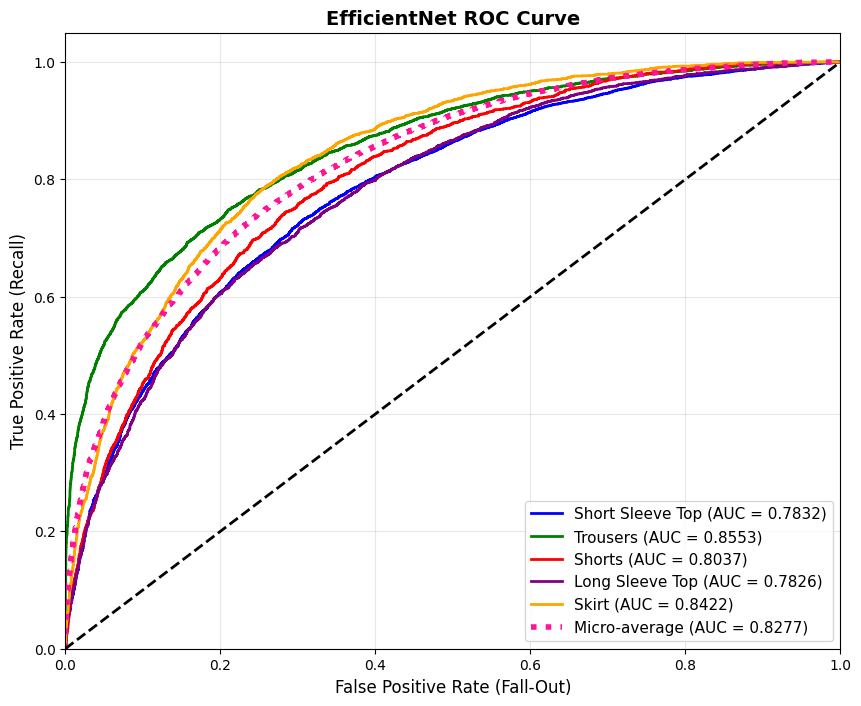

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, roc_curve, auc, accuracy_score
import warnings
from tqdm import tqdm
warnings.filterwarnings('ignore')

# ==========================================
# 5. METRICS & ROC EVALUATION SCRIPT (EfficientNet)
# ==========================================
print("Evaluating EfficientNet on the Test Set (Sigmoid Threshold = 0.5)...")
model_effnet.eval()

all_preds = []
all_labels = []
all_probs = [] 

# 2. Run the test set
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)
        
        outputs = model_effnet(images)
        
        # Sigmoid converts raw logits to percentages (Crucial for Multi-Label!)
        probs = torch.sigmoid(outputs)
        
        # Apply the 0.5 threshold to get the hard 1s and 0s
        preds = (probs > 0.5).float()
        
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

# 3. Stack arrays for scikit-learn
all_probs = np.vstack(all_probs)
all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

# 4. Calculate the Metrics
class_names = ["Short Sleeve Top", "Trousers", "Shorts", "Long Sleeve Top", "Skirt"]

micro_f1 = f1_score(all_labels, all_preds, average='micro', zero_division=0)
macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
micro_prec = precision_score(all_labels, all_preds, average='micro', zero_division=0)
micro_recall = recall_score(all_labels, all_preds, average='micro', zero_division=0)
final_accuracy = accuracy_score(all_labels, all_preds)

# 5. Print exactly matching your formatting
print("\n" + "="*45)
print("🚀 PROJECT METRICS (EfficientNet Classification)")
print("="*45)
print(f"Micro Precision: {micro_prec:.4f}")
print(f"Micro Recall:    {micro_recall:.4f}")
print(f"Micro F1-Score:  {micro_f1:.4f}")
print(f"Macro F1-Score:  {macro_f1:.4f}")
print("="*45)

print("\nPer-Category Breakdown:")
# Generate the multi-label classification report
report = classification_report(
    all_labels, 
    all_preds, 
    target_names=class_names, 
    zero_division=0
)
print(report)

# ==========================================
# 6. PLOT ROC CURVES
# ==========================================
plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'red', 'purple', 'orange']

# Calculate and plot ROC for each individual class
for i in range(5):
    fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.4f})')

# Calculate and plot the Micro-average ROC
fpr_micro, tpr_micro, _ = roc_curve(all_labels.ravel(), all_probs.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, color='deeppink', linestyle=':', lw=4, 
         label=f'Micro-average (AUC = {roc_auc_micro:.4f})')

# Graph Formatting
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Fall-Out)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('EfficientNet ROC Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)

plt.savefig("/kaggle/working/effnet_roc_curve.png", dpi=300, bbox_inches='tight')
plt.show()